# CNN Fine-Tuning (ResNet50) + ViT/CLIP — Deepfake Detection

Script and Comments taken and adapted from: Nora Webb Williams, Andreu Casas, John Wilkerson (2020) "Images as Data for Social Science Research"

Dataset: [OpenFake](https://huggingface.co/datasets/ComplexDataLab/OpenFake)

In [3]:
import os, time, json, pickle
import numpy as np
import pandas as pd
from pathlib import Path
from itertools import combinations

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from torchvision.models import ResNet50_Weights

from PIL import Image
import matplotlib.pyplot as plt
import imagehash
from datasets import load_dataset
from sklearn.model_selection import train_test_split
plt.ion()

In [4]:
# Keep in mind, the Dataset is very large
ds = load_dataset("ComplexDataLab/OpenFake", "core")

Resolving data files:   0%|          | 0/608 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/608 [00:00<?, ?it/s]

core/train-00000-of-00032-00016.parquet:   0%|          | 0.00/5.68G [00:00<?, ?B/s]

Cancellation requested; stopping current tasks.


KeyboardInterrupt: 

In [5]:
# Loading the cached parquet files (I did not download the complete dataset - this is only a subset, you will have other numbers, if you download the complete dataset)
from pathlib import Path
import pandas as pd

cache_path = Path.home() / ".cache/huggingface/hub/datasets--ComplexDataLab--OpenFake/blobs"
files = sorted([f for f in cache_path.iterdir() if "incomplete" not in f.name],
               key=lambda f: f.stat().st_size, reverse=True)

# Nur eine Datei, nur nötige Spalten
df_raw = pd.read_parquet(files[0], columns=["image", "label", "model"])
print(df_raw.shape)
print(df_raw["label"].value_counts())

(4000, 3)
label
real    2044
fake    1956
Name: count, dtype: int64


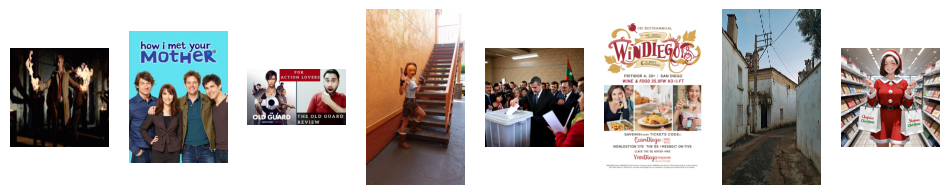

In [6]:
# Let's have a look at the first few images of the train dataset.
from PIL import Image
from io import BytesIO
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 8, figsize=(12, 3))

for ax, item in zip(axes, df_raw["image"][:8]):
    img = Image.open(BytesIO(item["bytes"]))
    ax.imshow(img)
    ax.axis("off")

plt.show()

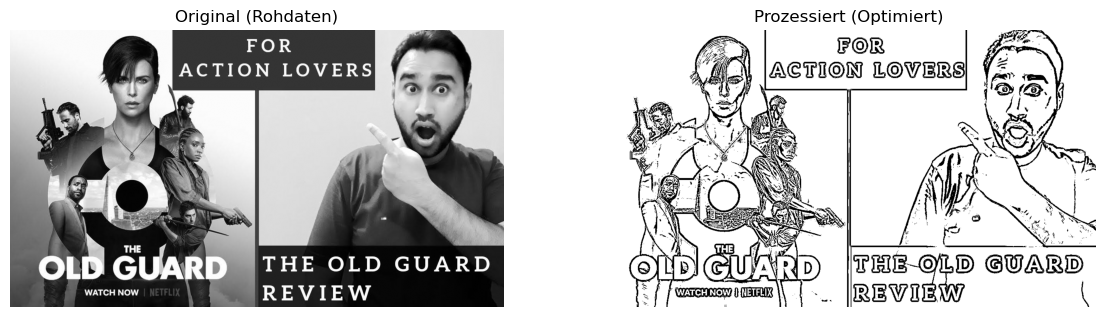

--- Extraktion Image 1 ---
(



In [7]:
import cv2
import numpy as np
from PIL import Image
from io import BytesIO
import pytesseract

def preprocess_image_advanced(image_bytes):
    # decode the image to a format that OpenCV can work with
    nparr = np.frombuffer(image_bytes, np.uint8)
    img = cv2.imdecode(nparr, cv2.IMREAD_COLOR)
    
    # reduce dimension: convert to grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # edge sharpening via unsharp masking
    # To enhance high-frequency components (character outlines)
    smoothed = cv2.GaussianBlur(gray, (5, 5), 0)
    sharpened = cv2.addWeighted(gray, 1.5, smoothed, -0.5, 0)
    
    # noise reduction: non-local means denoising
    # Reduces noise while preserving edges
    denoised = cv2.fastNlMeansDenoising(sharpened, None, h=10, 
                                        templateWindowSize=7, searchWindowSize=21)
    
    # adaptive thresholding
    # Compensates for uneven lighting conditions in the document
    processed = cv2.adaptiveThreshold(
        denoised, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, 
        cv2.THRESH_BINARY, 11, 2
    )
    
    return processed

def compare_preprocessing(item_bytes, index):
    # decode the image to a format that OpenCV can work with
    nparr = np.frombuffer(item_bytes, np.uint8)
    original_cv = cv2.imdecode(nparr, cv2.IMREAD_GRAYSCALE)
    enhanced_cv = preprocess_image_advanced(item_bytes)
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 7))
    axes[0].imshow(original_cv, cmap='gray')
    axes[0].set_title("Original (Rohdaten)")
    axes[0].axis('off')
    
    axes[1].imshow(enhanced_cv, cmap='gray')
    axes[1].set_title("Prozessiert (Optimiert)")
    axes[1].axis('off')
    plt.show()
    
    print(f"--- Extraktion Image {index} ---")
    print(pytesseract.image_to_string(enhanced_cv))

# test the preprocessing on the first image containing text in the dataset
compare_preprocessing(df_raw["image"][2]["bytes"], 1)

## 2. DataFrame Preparation & Train/Val/Test split

In [8]:
# Note that the original dataset already comes with train/val/test splits
# However, since we are only taking a subset of the data, we will do our
# own split to ensure we have enough data for each split and that the splits
# are stratified by label.

# Normalize Labels (might be unnecessary here, but just to be sure)
df_raw["label_str"] = df_raw["label"].str.lower()  # "real" / "fake"

# Extract PIL-Image from bytes
def to_pil(img):
    if isinstance(img, Image.Image):
        return img
    if isinstance(img, dict) and "bytes" in img:
        import io
        return Image.open(io.BytesIO(img["bytes"]))
    if isinstance(img, bytes):
        import io
        return Image.open(io.BytesIO(img))
    return img

df_raw["pil_image"] = df_raw["image"].apply(to_pil)

# Common dataset splits: 80/10/10 or 70/15/15 (train/val/test)
# The choice depends on dataset size and task
# Splits should usually be stratified by label to preserve class distribution

df_train, df_temp = train_test_split(df_raw, test_size=0.2, random_state=42,
                                      stratify=df_raw["label_str"])
df_val, df_test   = train_test_split(df_temp, test_size=0.5, random_state=42,
                                      stratify=df_temp["label_str"])

for split, d in [("train", df_train), ("val", df_val), ("test", df_test)]:
    d = d.copy()
    d["dataset_split"] = split

df_train = df_train.copy(); df_train["dataset_split"] = "train"
df_val   = df_val.copy();   df_val["dataset_split"]   = "val"
df_test  = df_test.copy();  df_test["dataset_split"]  = "test"

print(f"Train: {len(df_train)} | Val: {len(df_val)} | Test: {len(df_test)}")
print(df_train["label_str"].value_counts())

Train: 3200 | Val: 400 | Test: 400
label_str
real    1635
fake    1565
Name: count, dtype: int64


## 3. Modell-Konfiguration

In [9]:
num_classes          = 2
set_report_num       = 1
hyperparam_combo_num = 1
model_str            = "openfake"

set_learn_rate  = 0.0001
set_momentum    = 0.9
set_step_size   = 4 # every 4 epochs the learning rate will be decayed by a factor of gamma.  
set_gamma       = 0.1
set_iterations  = 10
set_batch_size  = 16

MODEL_SAVE_PATH = Path("./MODELS")
MODEL_SAVE_PATH.mkdir(exist_ok=True)

use_gpu = torch.cuda.is_available()
print(f"GPU verfügbar: {use_gpu}")
# I do not have a GPU on my machine.
# You can use Google Colab or Kaggle Notebooks to train with a GPU
# They both offer free GPU access (T4), but limited to 12h per session (for Google).
# If one has the ressources, one can also buy GPU access on e.g. Hugging Face

GPU verfügbar: False


## 4. Image Preprocessing

In [10]:
# These settings are depending on the pretrained model we are using (ResNet50 in our case)
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

def data_tranform(train=True):
    if train:
        return {
            "train": transforms.Compose([
                transforms.RandomResizedCrop(224),
                transforms.RandomHorizontalFlip(),
                transforms.ToTensor(),
                transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
            ]),
            "val": transforms.Compose([
                transforms.Resize(256),
                transforms.CenterCrop(224),
                transforms.ToTensor(),
                transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
            ]),
            "test": transforms.Compose([
                transforms.Resize(256),
                transforms.CenterCrop(224),
                transforms.ToTensor(),
                transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
            ])
        }
    return transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
    ])

preprocess = data_tranform(train=True)

## 5. Data-Leakage Check via pHash

Since we split the dataset by our own, we also need to check, that there are no Duplicates especially between train/test/val set, to prevent data leakage leading to over-confident model performance, since the model was trained on test/val data.

In [15]:
import imagehash

def safe_phash(img):
    try:
        return str(imagehash.phash(img.convert("RGB")))
    except:
        return None

In [16]:
def add_phash_with_stats(df, name):
    before = len(df)
    
    df["phash"] = df["pil_image"].map(safe_phash)
    df_clean = df.dropna(subset=["phash"])
    
    after = len(df_clean)
    
    print(f"{name}: removed {before - after} / {before}")
    
    return df_clean

In [17]:
df_train = add_phash_with_stats(df_train, "Train")
df_val = add_phash_with_stats(df_val, "Validation")
df_test = add_phash_with_stats(df_test, "Test")

Train: removed 0 / 3200
Validation: removed 0 / 400
Test: removed 0 / 400


In [ ]:
df_all = pd.concat([df_train, df_val, df_test], ignore_index=True)
before = len(df_all)
df_all = df_all.dropna(subset=["phash"])
after = len(df_all)

print(f"Total before: {before}")
print(f"Total after: {after}")
print(f"Removed total: {before - after}")

Total before: 4000
Total after: 4000
Removed total: 0


## 6. Custom Dataset & DataLoader

In [ ]:
LABEL_MAP = {"real": 0, "fake": 1}

class OpenFakeDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df        = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        img   = row["pil_image"].convert("RGB")
        label = LABEL_MAP[row["label_str"]]
        return self.transform(img) if self.transform else img, label


dataloaders = {
    # Shuffle training data to prevent the model from learning patterns based on the dataset's 
    # entry order (e.g., temporal bias)
    # Batch size controls gradient estimate stability; num_workers=0 ensures deterministic 
    # data loading for debugging
    "train": DataLoader(OpenFakeDataset(df_train, preprocess["train"]),
                        batch_size=set_batch_size, shuffle=True,  num_workers=0),
    # Use deterministic loading for val/test to ensure results are replicable and metrics remain stable across runs
    "val":   DataLoader(OpenFakeDataset(df_val,   preprocess["val"]),
                        batch_size=set_batch_size, shuffle=False, num_workers=0),
    "test":  DataLoader(OpenFakeDataset(df_test,  preprocess["test"]),
                        batch_size=set_batch_size, shuffle=False, num_workers=0),
}

dataset_sizes = {k: len(v.dataset) for k, v in dataloaders.items()}
class_names   = ["real", "fake"]
print(dataset_sizes)

{'train': 3200, 'val': 400, 'test': 400}


## 7. Initialise Model (ResNet50)

In [21]:
# Using pretrained ImageNet-1K weights for ResNet-50.
# Without pretrained weights, the model would start from random initialization,
# requiring significantly more data and training time.
# Pretraining provides useful visual features (edges, textures, shapes),
# which improves convergence and performance for real/fake classification.

model    = models.resnet50(weights=ResNet50_Weights.DEFAULT) #same as .ResNet50_Weights.IMAGENET1K_V2
num_ftrs = model.fc.in_features # get last fully connected layer
model.fc = nn.Linear(num_ftrs, num_classes) ## Adapt ResNet-50 output layer to match number of target classes - in our case two (fake/real)
# Freeze all layers except the last fully connected layer
for param in model.parameters():
    param.requires_grad = False

for param in model.fc.parameters():
    param.requires_grad = True

print(f"Output-Layer: {num_ftrs} -> {num_classes} (real / fake)")

Output-Layer: 2048 -> 2 (real / fake)


In [ ]:
criterion = nn.CrossEntropyLoss() # suitable for multi-class classification
optimizer = optim.SGD(model.fc.parameters(), lr=set_learn_rate, momentum=set_momentum) # SGD with momentum helps to accelerate convergence and escape local minima
scheduler = lr_scheduler.StepLR(optimizer, step_size=set_step_size, gamma=set_gamma) # Decays the learning rate by a factor of gamma every step_size epochs. This helps to fine-tune the model by reducing the learning rate as training progresses, allowing for finer adjustments to the weights and improving convergence
iter_num   = set_iterations # number of epochs to train - can be adjusted based on dataset size and convergence behavior. Too few epochs may lead to underfitting, while too many can cause overfitting. Monitoring validation performance can help determine the optimal number of epochs
report_num = set_report_num # how often to report training progress (e.g. every epoch, every 5 epochs, etc.) - this can be adjusted based on the total number of epochs and how quickly the model is learning. More frequent reporting can help monitor training, but may slow down the process if done too often
counter_models = 0 # counter for saving models with unique names based on hyperparameters and iteration number

## 8. Training

In [23]:
if use_gpu:
    model = model.cuda()

counter_models += 1
print(f"Training Modell {counter_models}: {model_str.upper()}")
print("=" * 40)

# - initialize a time object so we can check how long the training takes
since          = time.time()

# - initialize a matrix of weights (model parameters) and accuracy
#   object where we'll save the weights and accuracy info for the
#   most accurate weights-configuration
best_model_wts = model.state_dict()
best_acc = best_precision = best_recall = 0.0
loss_progress, acc_progress = [], []

for iteration in range(iter_num):
    if iteration % report_num == 0:
        print(f"Iteration {iteration}/{iter_num - 1}")
        print("-" * 10)

 # - each iteration has a training and testing phase
    for phase in ['train', 'test']:
        if phase == 'train':
            scheduler.step() # update model weights based on the learning rate scheduler
            model.train(True)  # set model to training mode
        else:
            model.train(False)  # set model to evaluate mode

        running_loss = running_corrects = 0
        running_preds, running_labels_list = [], []

        for inputs, labels_batch in dataloaders[phase]:
            if use_gpu:
                inputs, labels_batch = inputs.cuda(), labels_batch.cuda()

           # - gradients back to 0 (re-calculated in each iteration)
            optimizer.zero_grad()

            # - forward propagation: applying dot products
            outputs = model(inputs)
            _, preds = torch.max(outputs.data, 1)
            loss = criterion(outputs, labels_batch)

            # (only in training phase)
            # - backward propagation: calculate loss and gradients
            if phase == "train":
                loss.backward()
                optimizer.step()

           # - calculate accuracy statistics
            running_loss     += loss.item()
            running_corrects += torch.sum(preds == labels_batch.data).item()
            running_preds    += list(preds.cpu().numpy())
            running_labels_list += list(labels_batch.data.cpu().numpy())

        iter_loss = running_loss / dataset_sizes[phase]
        iter_acc  = running_corrects / dataset_sizes[phase]

        if sum(running_preds) > 0:
            tp             = sum(1 for p, l in zip(running_preds, running_labels_list) if p == 1 and l == 1)
            iter_precision = tp / float(sum(running_preds))
            iter_recall    = tp / float(sum(running_labels_list) or 1)
        else:
            iter_precision = iter_recall = 0

        # - report training progress once every N (e.g. 10) iterations
        if iteration % report_num == 0:
            print(f"{phase} Loss:{iter_loss:.4f} Acc:{iter_acc:.4f} "
                  f"Precision:{iter_precision:.4f} Recall:{iter_recall:.4f}")

        # - if this iteration's results are the best so far,
        #   saving a copy of this best model's weights and accuracy info
        if phase == "val":
            # - keep track of the evolution of the loss and accuracy during training
            loss_progress.append(iter_loss)
            acc_progress.append(iter_acc)
            if iter_acc > best_acc:
                best_acc, best_precision, best_recall = iter_acc, iter_precision, iter_recall
                best_model_wts = model.state_dict()

    if best_acc > 0.95 and best_precision > 0.95 and best_recall > 0.95:
        print("Gute Genauigkeit erreicht, Training beendet.")
        break
    
# - check how long it took to estimate the model and report
#   time and results for the most accurate model weights
time_elapsed = time.time() - since
print(f"\nFertig in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s")
print(f"Beste Val Accuracy: {best_acc:.4f}")

Training Modell 1: OPENFAKE
Iteration 0/9
----------


/var/folders/z8/r2r089pn34gcyk75h7kjbmfm0000gp/T/ipykernel_2157/3067007542.py:26: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler.step() # update model weights based on the learning rate scheduler


train Loss:0.0429 Acc:0.5453 Precision:0.5349 Recall:0.5387
test Loss:0.0418 Acc:0.5975 Precision:0.5778 Recall:0.6633
Iteration 1/9
----------
train Loss:0.0413 Acc:0.6256 Precision:0.6176 Recall:0.6160
test Loss:0.0408 Acc:0.6675 Precision:0.6352 Recall:0.7551
Iteration 2/9
----------
train Loss:0.0405 Acc:0.6366 Precision:0.6342 Recall:0.6070
test Loss:0.0399 Acc:0.6625 Precision:0.6432 Recall:0.6990
Iteration 3/9
----------


: 

In [ ]:
model.load_state_dict(best_model_wts)

accuracy_summary = dict(
    acc=best_acc, precision=best_precision, recall=best_recall,
    lr=set_learn_rate, momentum=set_momentum, step_size=set_step_size,
    gamma=set_gamma, max_iters=set_iterations, batch_size=set_batch_size,
    acc_progress=acc_progress, loss_progress=loss_progress
)
print(accuracy_summary)

save_path = MODEL_SAVE_PATH / f"{model_str}_{hyperparam_combo_num}.pth"
torch.save(model, save_path)
print(f"Modell gespeichert: {save_path}")

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
ax1.plot(loss_progress); ax1.set(title="Val Loss",     xlabel="Iteration", ylabel="Loss")
ax2.plot(acc_progress);  ax2.set(title="Val Accuracy", xlabel="Iteration", ylabel="Accuracy")
plt.tight_layout(); plt.show()

## 9. How does the model perform on Reddit Test-Set?

In [ ]:
model_new = torch.load(MODEL_SAVE_PATH / f"{model_str}_{hyperparam_combo_num}.pth")
model_new.eval()

preprocess_infer = data_tranform(train=False)
softmax = nn.Softmax(dim=1)

sample_real = df_test[df_test["label_str"] == "REAL"].head(5)
sample_fake = df_test[df_test["label_str"] == "FAKE"].head(5)
test_samples = pd.concat([sample_real, sample_fake]).reset_index(drop=True)

output_data = []
for _, row in test_samples.iterrows():
    img = row["pil_image"].convert("RGB")
    var = Variable(preprocess_infer(img).unsqueeze(0))
    if use_gpu: var = var.cuda()

    with torch.no_grad():
        pred = model_new(var)

    probs, indices = softmax(pred).cpu().sort(dim=1)
    output_data.append({
        "true_label": row["label_str"],
        "pred_label": class_names[indices[0][-1].item()],
        "prob_REAL":  round(probs[0][0].item(), 3),
        "prob_FAKE":  round(probs[0][1].item(), 3),
        "model":      row.get("model", ""),
    })

output_df = pd.DataFrame(output_data)
output_df

## Vision Transformer (CLIP)

Model architecture: CLIP (Contrastive Language-Image Pretraining)
CLIP uses a Vision Transformer encoder (but some models also use CNNs (ResNet)) and Text Transformers
that processes images as patch embeddings instead of convolutional filters, 
learns a joint embedding space for images and text
and enables zero-shot classification via image-text alignment

In [11]:
from transformers import pipeline
import torch


use_gpu = 0 if torch.cuda.is_available() else -1

model_id = "openai/clip-vit-base-patch32"

clip = pipeline(
    task="zero-shot-image-classification",
    model=model_id,
    device=use_gpu
)

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

In [14]:
df_raw = pd.read_parquet(files[0], columns=["image", "label", "model"])
df_raw = df_raw.sample(n=100, random_state=42) # random_state für Reproduzierbarkeit

print(df_raw.shape)
print(df_raw["label"].value_counts())

(100, 3)
label
real    56
fake    44
Name: count, dtype: int64


In [15]:
from PIL import Image
import io

labels = ["real", "fake"]
clip_results = []

for _, row in df_raw.iterrows():
    img_data = row["image"]["bytes"] 
    img = Image.open(io.BytesIO(img_data)).convert("RGB")
    out = clip(img, candidate_labels=labels)
    
    # Scores als Dict aufschlüsseln
    scores = {item["label"]: item["score"] for item in out}
    
    clip_results.append({
        "true_label":  row["label"],
        "clip_pred":   out[0]["label"],            
        "score_fake":  round(scores["fake"], 3),  
        "score_real":  round(scores["real"], 3), 
    })
#sorry for the confusion during the seminar - I depicted both Clip-scores for real and fake beneath each other
clip_df = pd.DataFrame(clip_results)
print(clip_df.head())

  true_label clip_pred  score_fake  score_real
0       fake      fake       0.651       0.349
1       fake      fake       0.842       0.158
2       fake      real       0.349       0.651
3       fake      real       0.379       0.621
4       fake      fake       0.507       0.493
